# 04 — Modelling

Builds the model ladder. Each rung adds information; the comparison is between
**feature sets**, not between algorithms.

| # | Features | Question |
|---|---|---|
| 0 | constant (train median) | What does predicting nothing cost? |
| 1 | `vote_average` only | Am I just an average viewer? |
| 2 | Block F — film metadata | Does knowing what kind of film it is beat the crowd? |
| 3 | + Block H — personal history | Does my viewing history add anything? |
| 4 | + Block R — review-derived | Does what I've written add anything beyond what I've rated? |

**Input:** `data/interim/modelling_base.csv`

Two model families throughout — Ridge and Random Forest — with the same
hyperparameter budget at every rung, so the comparison stays about features.

## 1. Load and split

Chronological 80/20. Re-sorted on load because CSV round-trips can reorder, and
chronological order is load-bearing.

Date ranges printed separately as visible confirmation the two periods don't overlap.


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("data/interim/modelling_base.csv", parse_dates=["watched_date"])
df = df.sort_values("watched_date").reset_index(drop=True)

split_idx = int(len(df) * 0.8)
train = df[:split_idx].copy()
test  = df[split_idx:].copy()

print(f"train {len(train)}  test {len(test)}")
print(f"train: {train['watched_date'].min().date()} -> {train['watched_date'].max().date()}")
print(f"test : {test['watched_date'].min().date()} -> {test['watched_date'].max().date()}")

train 953  test 239
train: 2021-12-25 -> 2024-09-27
test : 2024-10-03 -> 2026-08-31


## 2. Evaluation

Written once and reused for every model, so every rung is scored identically.

`round(pred * 2) / 2` snaps a continuous prediction to the nearest half-star;
`clip` keeps it inside the valid 0.5–5.0 range, since a model can predict 5.3.

Both raw and rounded MAE are reported — rounding can move the number in either
direction. `exact` and `within_half` are the interpretable metrics: what fraction land
on the precise half-star, and what fraction are within one.


In [3]:
def evaluate(y_true, y_pred, name=""):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rounded = np.clip(np.round(y_pred * 2) / 2, 0.5, 5.0)

    return {
        "model":        name,
        "MAE":          np.abs(y_true - y_pred).mean(),
        "RMSE":         np.sqrt(((y_true - y_pred) ** 2).mean()),
        "MAE_rounded":  np.abs(y_true - rounded).mean(),
        "exact":        (rounded == y_true).mean(),
        "within_half":  (np.abs(y_true - rounded) <= 0.5).mean(),
    }

## 3. Model 0 — the baseline

Predicting the training median for every test film. Every later model is measured
against this.

`results` is a running list so each model appends to it and the comparison table
builds itself.


In [4]:
results = []

baseline = train["rating"].median()
pred_0 = np.full(len(test), baseline)
results.append(evaluate(test["rating"], pred_0, "0 — constant (train median)"))

pd.DataFrame(results).round(3)

,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632


Predicting 3.5 for everything hits the exact rating 19.7% of the time and lands
within half a star 63.2% of the time. Worth stating plainly in the presentation — it
frames the difficulty better than an MAE alone.

`MAE` and `MAE_rounded` are identical here because 3.5 is already a valid half-star.
They diverge once models predict continuous values.


## 4. Model 1 — crowd score only

A one-feature linear regression rather than the raw halved TMDB score, so the model
learns the scaling and any systematic offset itself.


In [5]:
X1_train = train[["vote_average"]]
X1_test  = test[["vote_average"]]

m1 = LinearRegression().fit(X1_train, train["rating"])
pred_1 = m1.predict(X1_test)

results.append(evaluate(test["rating"], pred_1, "1 — crowd score only"))
print(f"slope {m1.coef_[0]:.3f}  intercept {m1.intercept_:.3f}")
pd.DataFrame(results).round(3)

slope 0.598  intercept -0.716


,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632
1,1 — crowd score only,0.656,0.826,0.659,0.213,0.636


**Slope 0.598.** On TMDB's 0–10 scale, a one-point rise moves the predicted
rating by 0.6 stars — equivalent to 1.19 on a like-for-like scale. So personal ratings
move *more* than crowd scores do, not less.

TMDB scores cluster tightly (most films between 6 and 8), so the model has to amplify
small differences in a narrow input to predict a wide output. It is stretching a
compressed signal.

`within_half` barely moved (63.2% → 63.6%), so the crowd score is shaving large errors
rather than producing more close predictions.


## 5. Bootstrap confidence intervals

The 239 test films are one sample from the many test sets that might have occurred.
Resampling them with replacement and recomputing MAE shows how much the number would
wobble under a different draw.

`rng.integers(0, n, n)` draws n indices with replacement — some films appear twice,
some not at all — which is what makes each resample a plausible alternative test set.


In [6]:
def bootstrap_mae(y_true, y_pred, n_boot=2000, seed=0):
    """95% confidence interval for MAE by resampling the test set."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rng = np.random.default_rng(seed)

    n = len(y_true)
    maes = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        maes[i] = np.abs(y_true[idx] - y_pred[idx]).mean()

    return np.percentile(maes, [2.5, 97.5])

In [7]:
for name, pred in [("Model 0", pred_0), ("Model 1", pred_1)]:
    lo, hi = bootstrap_mae(test["rating"], pred)
    print(f"{name}: MAE {np.abs(test['rating'] - pred).mean():.3f}  95% CI [{lo:.3f}, {hi:.3f}]")

Model 0: MAE 0.682  95% CI [0.615, 0.751]
Model 1: MAE 0.656  95% CI [0.596, 0.721]


The two intervals overlap almost entirely, so Model 1's 0.025 gain is **not**
distinguishable from noise.

Intervals are roughly ±0.06 wide, which sets the bar for the whole project: a model
needs to beat the baseline by something like 0.05+ before the improvement can be
claimed.


### Paired comparison

Comparing two independent intervals is conservative — the models predict the **same**
films, so their errors are correlated. Resampling the same indices for both cancels
the shared difficulty of the films and gives a more sensitive test.

If the interval for the *difference* excludes zero, the improvement is real even when
the individual intervals overlap.


In [8]:
def bootstrap_mae_diff(y_true, pred_a, pred_b, n_boot=2000, seed=0):
    """95% CI for MAE(a) - MAE(b), resampling the same films for both."""
    y_true = np.asarray(y_true)
    err_a = np.abs(y_true - np.asarray(pred_a))
    err_b = np.abs(y_true - np.asarray(pred_b))
    rng = np.random.default_rng(seed)

    n = len(y_true)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        diffs[i] = err_a[idx].mean() - err_b[idx].mean()

    return diffs.mean(), np.percentile(diffs, [2.5, 97.5])

In [9]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_0, pred_1)
print(f"Model 0 - Model 1: {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Model 0 - Model 1: +0.025  95% CI [-0.022, +0.074]


Spans zero. Even paired, the crowd score does not reliably beat predicting the
median.

This is a useful early result: **Model 1 is a weak baseline**, meaning the crowd score
barely knows this viewer. That leaves substantial room for the personal feature blocks.


---

## 6. Block F — film metadata

### Genre vocabulary

Derived from **training data only**. Building it from the full dataset would create
columns for genres that appear only in test films — a leak, and one that breaks when
the model is later applied to unseen films.

`min_count=20` matches the EDA threshold: a genre with three films cannot support a
stable estimate and only adds a near-empty column. Rare genres get no column, and
those films are represented by their other genres.


In [10]:
def genre_vocabulary(series, min_count=20):
    counts = (series.fillna("").str.split("|").explode()
              .replace("", np.nan).dropna().value_counts())
    return sorted(counts[counts >= min_count].index)

GENRES = genre_vocabulary(train["genres"])
print(f"{len(GENRES)} genres: {GENRES}")

15 genres: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War']


In [11]:
def count_uncovered(series, vocab):
    has_none = series.fillna("").apply(
        lambda s: not any(g in s.split("|") for g in vocab))
    return has_none.sum()

print(f"train films with no vocabulary genre: {count_uncovered(train['genres'], GENRES)}")
print(f"test  films with no vocabulary genre: {count_uncovered(test['genres'], GENRES)}")

train films with no vocabulary genre: 2
test  films with no vocabulary genre: 3


Only 5 films of 1,192 end up with no vocabulary genre, so the threshold is not
too aggressive.


### Multi-hot encoding

**Multi-hot, not one-hot.** One-hot assumes exactly one category per row; genres are
multi-label — *Dune* is Science Fiction *and* Adventure, so both columns fire.

This also means there is no dummy variable trap: knowing a film is not Drama or Comedy
tells you nothing about whether it is Horror, so all 15 columns are kept.

`vocab` is a parameter rather than a global, which is what allows the same columns to
be produced for train, test, and later unseen films.


In [12]:
def encode_genres(series, vocab):
    """One binary column per genre in the vocabulary."""
    split = series.fillna("").str.split("|")
    return pd.DataFrame(
        {f"genre_{g}": split.apply(lambda gs: int(g in gs)) for g in vocab},
        index=series.index,
    )

g_train = encode_genres(train["genres"], GENRES)
print(g_train.shape)
print(g_train.sum().sort_values(ascending=False).head())

(953, 15)
genre_Drama       617
genre_Comedy      241
genre_Thriller    238
genre_Romance     164
genre_Crime       148
dtype: int64


### Language

Genuinely one-hot — a film has exactly one original language — but high-cardinality,
so it needs a top-N treatment.

`pd.get_dummies` is avoided deliberately: it builds columns from whatever data it is
given, so train and test would produce different column sets. It would also give a
column to languages with two or three films, which is noise a model can overfit.
(`sklearn`'s `OneHotEncoder(handle_unknown="ignore")` is the production equivalent;
hand-rolling here makes the train-fitted vocabulary explicit.)


In [13]:
def top_n_vocabulary(series, n=10, min_count=15):
    """Most frequent values in the training data, above a minimum count."""
    counts = series.dropna().value_counts()
    return sorted(counts[counts >= min_count].head(n).index)

LANGUAGES = top_n_vocabulary(train["original_language"], n=10)
print(f"{len(LANGUAGES)} languages: {LANGUAGES}")
print()
print(train["original_language"].value_counts().head(15))

5 languages: ['en', 'fr', 'ja', 'ko', 'zh']

original_language
en    767
ja     45
fr     38
ko     19
zh     15
de      9
it      8
sv      8
es      8
da      5
pl      4
cn      4
ru      4
el      3
th      2
Name: count, dtype: int64


The `min_count=15` floor binds before the `n=10` cap — German at 9 films is the
first exclusion. Five columns plus an implicit "other" covering ~60 films.

English dominates at 767 of 953 films (80%), so realistically the model learns
"English vs not" and the finer distinctions stay weak.


In [14]:
def encode_categorical(series, vocab, prefix):
    """One binary column per vocabulary value, plus an 'other' catch-all."""
    out = pd.DataFrame(
        {f"{prefix}_{v}": (series == v).astype(int) for v in vocab},
        index=series.index,
    )
    out[f"{prefix}_other"] = (~series.isin(vocab)).astype(int)
    return out

l_train = encode_categorical(train["original_language"], LANGUAGES, "lang")
print(l_train.shape)
print(l_train.sum())

(953, 6)
lang_en       767
lang_fr        38
lang_ja        45
lang_ko        19
lang_zh        15
lang_other     69
dtype: int64


The explicit `other` column matters: without it, a film in an excluded language
would be all-zeros across every language column, indistinguishable from missing data.


### Numeric features

Distributions inspected **before** deciding on transforms.


In [15]:
CANDIDATES = ["runtime", "vote_average", "vote_count", "popularity",
              "film_year", "review_words"]

print(train[CANDIDATES].describe().round(2))


       runtime  vote_average  vote_count  popularity  film_year  review_words
count   953.00        953.00      953.00      953.00     953.00        953.00
mean    117.58          7.18     4719.56       11.36    2004.60        111.75
std      25.46          0.66     5358.05       10.02      18.29        107.80
min      45.00          4.29       12.00        0.32    1931.00          1.00
25%     100.00          6.79     1098.00        5.05    1996.00         26.00
50%     114.00          7.23     2989.00        8.36    2010.00         84.00
75%     131.00          7.64     6322.00       14.45    2019.00        164.00
max     345.00          8.69    40184.00       81.22    2024.00        861.00


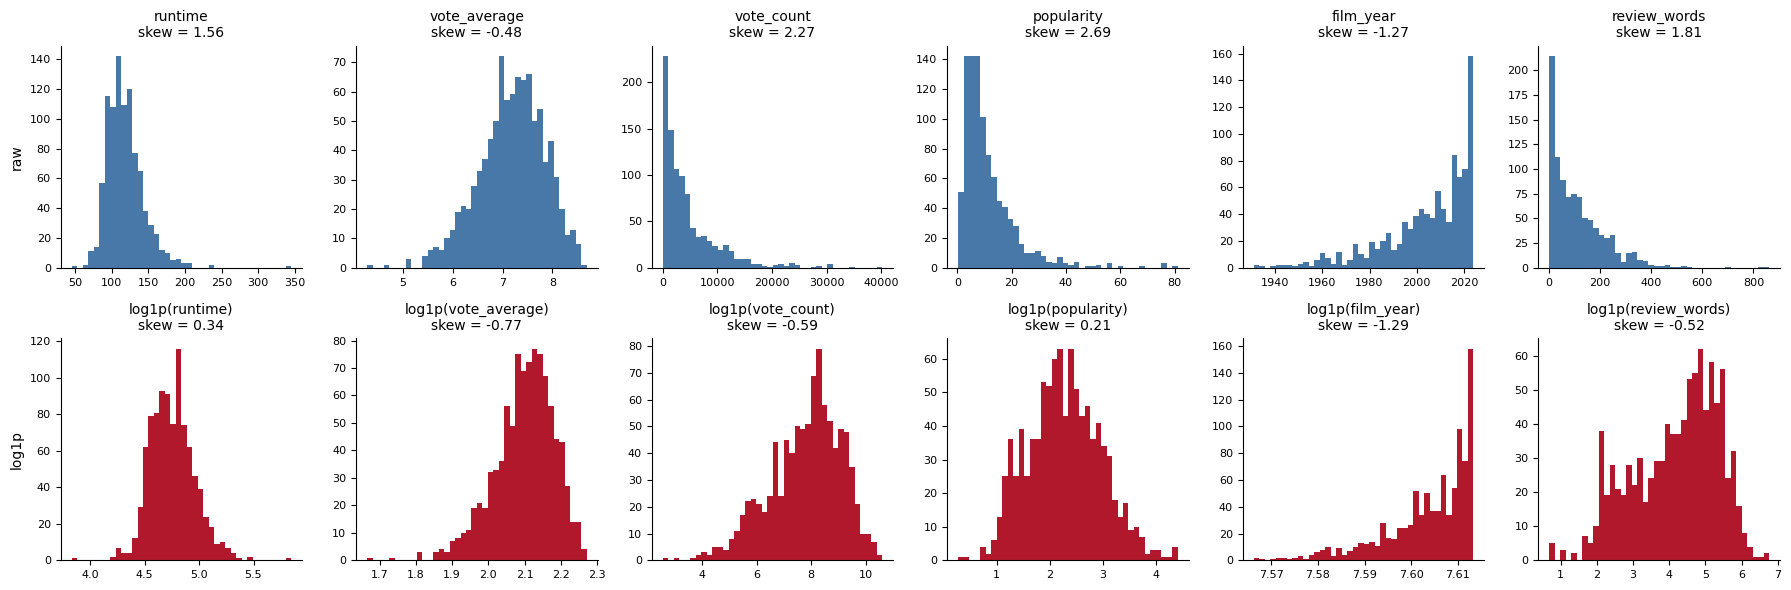

In [16]:
fig, axes = plt.subplots(2, len(CANDIDATES), figsize=(3 * len(CANDIDATES), 6))

for j, col in enumerate(CANDIDATES):
    raw = train[col].dropna()
    axes[0, j].hist(raw, bins=40, color="#4878a8")
    axes[0, j].set_title(f"{col}\nskew = {raw.skew():.2f}", fontsize=10)

    logged = np.log1p(raw)
    axes[1, j].hist(logged, bins=40, color="#b2182b")
    axes[1, j].set_title(f"log1p({col})\nskew = {logged.skew():.2f}", fontsize=10)

for ax in axes.flat:
    ax.tick_params(labelsize=8)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

axes[0, 0].set_ylabel("raw")
axes[1, 0].set_ylabel("log1p")
plt.tight_layout()
plt.show()

Reading the skew figures (near 0 is symmetric, above ~1 is substantially
right-skewed), the decision rule is whether logging moves skew *closer* to zero:

| Feature | raw | log1p | decision |
|---|---|---|---|
| `popularity` | 2.69 | 0.21 | **log** |
| `vote_count` | 2.27 | −0.59 | **log** |
| `review_words` | 1.81 | −0.52 | **log** |
| `runtime` | 1.56 | 0.34 | **log** |
| `vote_average` | −0.48 | −0.77 | plain — logging worsens it |
| `film_year` | −1.27 | −1.29 | plain — logging is meaningless here |

`runtime` was initially assumed symmetric from the summary statistics; the histogram
shows a clear right tail (the 345-minute Lav Diaz), and the skew figure confirms
logging helps.

**Why log rather than just scale.** `StandardScaler` is a linear transform — it
changes units but leaves the distribution's *shape* untouched, so a skewed variable
stays skewed. Ridge fits one coefficient across the whole range, which without logging
forces it to treat a 3,000-vote gap identically whether it separates 12 from 3,000
(meaningful) or 37,000 from 40,000 (meaningless). Logging makes equal *ratios* span
equal distances. Log first for shape, then scale for the L2 penalty.

`log1p` rather than `log` because it computes log(1+x) and handles zero safely —
`popularity` can be 0.

`film_year`'s −1.27 skew is real and untreated. Random Forest handles it natively;
if Ridge underperforms on older films, a decade bucket or `film_age` is the fallback.


In [17]:
LOG_NUMERIC = ["runtime", "vote_count", "popularity", "review_words"]
PLAIN_NUMERIC = ["vote_average", "film_year"]

def encode_numeric(frame):
    out = frame[PLAIN_NUMERIC].copy()
    for col in LOG_NUMERIC:
        out[f"log_{col}"] = np.log1p(frame[col])
    return out

n_train = encode_numeric(train)
print(n_train.describe().round(2))

       vote_average  film_year  log_runtime  log_vote_count  log_popularity  \
count        953.00     953.00       953.00          953.00          953.00   
mean           7.18    2004.60         4.75            7.80            2.27   
std            0.66      18.29         0.20            1.31            0.68   
min            4.29    1931.00         3.83            2.56            0.28   
25%            6.79    1996.00         4.62            7.00            1.80   
50%            7.23    2010.00         4.74            8.00            2.24   
75%            7.64    2019.00         4.88            8.75            2.74   
max            8.69    2024.00         5.85           10.60            4.41   

       log_review_words  
count            953.00  
mean               4.18  
std                1.18  
min                0.69  
25%                3.30  
50%                4.44  
75%                5.11  
max                6.76  


### Assemble Block F

6 numeric + 15 genre + 6 language + 1 franchise flag = 28 columns.

Deliberately excluded: **director, cast, cinematographer** (high-cardinality — they
enter as historical means in Block H), **keywords** and **overview** (held for Block
R), **`origin_country`** (near-duplicate of language).

So Model 2 answers "how much is predictable from what the film objectively *is*".
Everything about the viewer comes later.

Three checks in one cell because all three fail silently: mismatched column *order*
would misalign features without raising, and nulls surface later as an opaque `fit`
error.


In [18]:
def build_features_F(frame):
    """Block F — film metadata only."""
    return pd.concat([
        encode_numeric(frame),
        encode_genres(frame["genres"], GENRES),
        encode_categorical(frame["original_language"], LANGUAGES, "lang"),
        frame[["in_collection"]].astype(int),
    ], axis=1)

X_train = build_features_F(train)
X_test  = build_features_F(test)

print(f"train {X_train.shape}  test {X_test.shape}")
print(f"columns match: {list(X_train.columns) == list(X_test.columns)}")
print(f"nulls — train {X_train.isna().sum().sum()}, test {X_test.isna().sum().sum()}")

train (953, 28)  test (239, 28)
columns match: True
nulls — train 0, test 0


### Model 2 — Ridge

`make_pipeline` bundles the scaler with the model so scaling is fitted on train and
applied to test automatically — doing it manually invites fitting the scaler on the
full dataset, which leaks the test distribution.

`alpha=1.0` as a starting point; tuned properly with `TimeSeriesSplit` once both
families are in place, so every rung gets the same budget.


In [19]:
ridge_2 = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge_2.fit(X_train, train["rating"])
pred_2r = ridge_2.predict(X_test)

results.append(evaluate(test["rating"], pred_2r, "2 — film metadata (Ridge)"))
pd.DataFrame(results).round(3)

,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632
1,1 — crowd score only,0.656,0.826,0.659,0.213,0.636
2,2 — film metadata (Ridge),0.600,0.778,0.592,0.268,0.695


First clear improvement. **`MAE_rounded` (0.592) beats raw MAE (0.600)** — the
first divergence, and rounding helps: continuous predictions like 3.87 snap to a real
rating. `exact` rose 21.3% → 26.8% and `within_half` 63.6% → 69.5%, so unlike Model 1
this produces genuinely more close predictions rather than only shaving large errors.


In [20]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_0, pred_2r)
print(f"Model 0 - Model 2 (Ridge): {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Model 0 - Model 2 (Ridge): +0.082  95% CI [+0.027, +0.136]


In [21]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_1, pred_2r)
print(f"Model 1 - Model 2 (Ridge): {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Model 1 - Model 2 (Ridge): +0.056  95% CI [+0.025, +0.090]


**Both intervals exclude zero.** Film metadata beats the baseline by 0.082
[0.027, 0.136] and beats the crowd score by 0.056 [0.025, 0.090].

The Model 1 comparison is tighter because the two models share `vote_average`, so
their errors are more correlated and pairing cancels more noise.

Note the contrast: consensus opinion alone couldn't clear zero, but structural facts
about the film — genre, runtime, era, language, reach — can.


### Model 2 — Random Forest

No scaler: trees split on rank, so scaling is irrelevant. The log transforms are also
irrelevant to a forest but harmless, and one shared feature matrix is worth more than
marginal purity.


In [22]:
rf_2 = RandomForestRegressor(n_estimators=500, random_state=0, n_jobs=-1)
rf_2.fit(X_train, train["rating"])
pred_2f = rf_2.predict(X_test)

results.append(evaluate(test["rating"], pred_2f, "2 — film metadata (RF)"))
pd.DataFrame(results).round(3)

,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632
1,1 — crowd score only,0.656,0.826,0.659,0.213,0.636
2,2 — film metadata (Ridge),0.600,0.778,0.592,0.268,0.695
3,2 — film metadata (RF),0.573,0.721,0.556,0.255,0.732


**The forest wins, contrary to expectation.** MAE 0.573 vs Ridge's 0.600, and
0.556 vs 0.592 once rounded. The prior reasoning — that 953 rows would be too few for a
forest to beat a well-regularised linear model — was sound but empirically wrong, which
is itself the argument for running both families rather than choosing on theory.

`exact` fell slightly (25.5% vs 26.8%) while `within_half` rose sharply (73.2% vs
69.5%), and RMSE dropped (0.721 vs 0.778). Averaging 500 trees pulls predictions toward
the middle of the distribution — costing the occasional extreme hit but avoiding
confident wrong answers. With ratings concentrated in 3.0–4.0, staying near the middle
is a good bet.


In [23]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_2r, pred_2f)
print(f"Ridge - RF (Model 2): {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Ridge - RF (Model 2): +0.027  95% CI [-0.022, +0.078]


In [24]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_0, pred_2f)
print(f"Model 0 - Model 2 (RF): {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Model 0 - Model 2 (RF): +0.109  95% CI [+0.040, +0.176]


**Ridge vs RF spans zero** — the families are equivalent on Block F, so both
carry forward and the ladder stays a comparison of features rather than algorithms.

**RF vs Model 0: +0.109 [0.040, 0.176]**, clearing zero comfortably.


---

## 7. Block H — personal history

Every feature here answers: *at the moment I watched this film, what did my rating
history look like?* So each row's features must be computed from **strictly earlier
rows only** — an expanding window.

**This applies to training rows as well as test rows.** Computing "mean rating for
Drama" across the whole training set and attaching it to every Drama row would let
each row see its own rating. Training fit would look excellent, test performance would
disappoint, and the feature importances would lie about what mattered.

The features are also undefined at the start — the first film has no history, the first
Korean film has no Korean history. Hence a `*_n_*` count companion for every aggregate,
so the model can distinguish a mean over one film from a mean over thirteen.


### The leakage prevention, demonstrated

`shift(1)` is the whole mechanism: it moves each rating down one position so
`expanding().mean()` at row *n* covers rows 1 to *n−1*, never row *n* itself.

Verified by hand: row 0 is NaN, row 1 equals row 0's rating, row 2 is (2.0+4.0)/2 =
3.0, row 3 is 10.5/3 = 3.5, row 4 is 14.5/4 = 3.625, row 5 is 18.5/5 = 3.7.


In [25]:
def expanding_mean(ratings):
    """Mean of all strictly-earlier values. NaN for the first row."""
    return ratings.shift(1).expanding().mean()

check = df[["watched_date", "film_title", "rating"]].head(6).copy()
check["prior_mean"] = expanding_mean(df["rating"]).head(6)
check


,watched_date,film_title,rating,prior_mean
0,2021-12-25,Don't Look Up,2.0,NaN
1,2021-12-26,Tenet,4.0,2.000
2,2021-12-26,Memories of Murder,4.5,3.000
3,2021-12-27,Dead Poets Society,4.0,3.500
4,2021-12-30,The Mitchells vs. the Machines,4.0,3.625
5,2022-01-01,Little Women,4.0,3.700


Note that rows 1 and 2 share a watched date — *Tenet* precedes *Memories of
Murder* only because of the `logged_date` tiebreaker set in `01`. Within a single day
the ordering is somewhat arbitrary, since Letterboxd does not record time of day.
A minor imprecision affecting few rows; recorded as a limitation rather than fixed.


### Grouped history

Same pattern restricted to rows sharing a key — genre, director, language, decade.

`transform` is what keeps the result aligned to the original index; `groupby().expanding()`
would return a multi-index needing reassembly. Only the **value** is shifted, never the
key — shifting both would group each row under the previous row's genre.


In [26]:
def expanding_group_mean(frame, key_col, value_col="rating"):
    """Mean of value_col over strictly-earlier rows sharing the same key."""
    return (frame.groupby(key_col)[value_col]
                 .transform(lambda s: s.shift(1).expanding().mean()))

In [27]:
d = df[["watched_date", "film_title", "original_language", "rating"]].copy()
d["lang_prior_mean"] = expanding_group_mean(df, "original_language")

d[d["original_language"] == "ja"].head(6)

,watched_date,film_title,original_language,rating,lang_prior_mean
83,2022-03-08,Drive My Car,ja,4.5,NaN
156,2022-05-04,Perfect Blue,ja,5.0,4.500
161,2022-05-11,Paprika,ja,4.0,4.750
189,2022-06-08,House,ja,4.0,4.500
197,2022-06-16,My Neighbor Totoro,ja,5.0,4.375
203,2022-06-19,Kiki's Delivery Service,ja,5.0,4.500


Verified on Japanese-language films: *Drive My Car* NaN, *Perfect Blue* 4.5,
*Paprika* (4.5+5.0)/2 = 4.75, *House* 13.5/3 = 4.5, *Totoro* 17.5/4 = 4.375.

The non-contiguous index (83, 156, 161…) confirms alignment — `transform` mapped each
group's expanding mean back to its original row positions.


The count companion. `count()` returns **0** rather than NaN when a group exists
but has no prior rows, which is the correct semantics: "zero prior films by this
director" is a fact, not missing data.


In [28]:
def expanding_group_count(frame, key_col, value_col="rating"):
    """Number of strictly-earlier rows sharing the same key."""
    return (frame.groupby(key_col)[value_col]
                 .transform(lambda s: s.shift(1).expanding().count()))

### Genre history

Genre is multi-label, so it does not fit the `groupby` pattern — a film carries several
genres and needs its historical means aggregated across them.

An explicit loop rather than a vectorised expression. Slower, but 1,192 rows is
nothing, and the leakage logic is **visible**: the running totals update *after* the
row's features are recorded, which is the loop equivalent of `shift(1)`.

`seen` filters to genres that actually have history, so a film that is Drama (40 prior)
and Documentary (0 prior) averages only the Drama mean rather than being dragged by an
empty one.


In [29]:
def genre_history(frame, vocab):
    """Mean of prior ratings across this film's genres, and total prior exposure."""
    totals = {g: 0.0 for g in vocab}
    counts = {g: 0 for g in vocab}
    means, exposure = [], []

    for genres_str, rating in zip(frame["genres"].fillna(""), frame["rating"]):
        gs = [g for g in genres_str.split("|") if g in vocab]

        seen = [g for g in gs if counts[g] > 0]
        means.append(np.mean([totals[g] / counts[g] for g in seen]) if seen else np.nan)
        exposure.append(sum(counts[g] for g in gs))

        for g in gs:                      # update AFTER recording, never before
            totals[g] += rating
            counts[g] += 1

    return pd.Series(means, index=frame.index), pd.Series(exposure, index=frame.index)

In [30]:
g_mean, g_exposure = genre_history(df, GENRES)

check = df[["watched_date", "film_title", "genres", "rating"]].head(8).copy()
check["genre_prior_mean"] = g_mean.head(8)
check["genre_exposure"] = g_exposure.head(8)
check

,watched_date,film_title,genres,rating,genre_prior_mean,genre_exposure
0,2021-12-25,Don't Look Up,Comedy|Science Fiction|Drama,2.0,NaN,0
1,2021-12-26,Tenet,Action|Thriller|Science Fiction,4.0,2.000000,1
2,2021-12-26,Memories of Murder,Crime|Drama|Thriller,4.5,3.000000,2
3,2021-12-27,Dead Poets Society,Drama,4.0,3.250000,2
4,2021-12-30,The Mitchells vs. the Machines,Animation|Adventure|Comedy,4.0,2.000000,1
5,2022-01-01,Little Women,Drama|Romance,4.0,3.500000,3
6,2022-01-02,"Girl, Interrupted",Drama,3.5,3.625000,4
7,2022-01-03,The Nice Guys,Comedy|Crime|Action,4.5,3.833333,4


Cross-checked independently against the raw data. *The Nice Guys* (Comedy /
Crime / Action) at row 7: Comedy mean 3.0 from two films, Crime 4.5 from one, Action
4.0 from one — average 3.833, exposure 4. Matches the function exactly.


In [31]:
for g in ["Comedy", "Crime", "Action"]:
    prior = df.iloc[:7]
    hits = prior[prior["genres"].str.contains(g, na=False)]
    print(f"{g:8s} n={len(hits)}  mean={hits['rating'].mean():.3f}  {list(hits['film_title'])}")

Comedy   n=2  mean=3.000  ["Don't Look Up", 'The Mitchells vs. the Machines']
Crime    n=1  mean=4.500  ['Memories of Murder']
Action   n=1  mean=4.000  ['Tenet']


### Imputation

Neither Ridge nor Random Forest accepts NaN, so the missing group means need filling —
and this is the decision deliberately kept explicit rather than delegated to a model's
internal NaN handling.

**The fill is `hist_mean_all`** — the running overall mean *at that point in time*.
"I know nothing about this director, so my best guess is my average rating so far."
Filling with a global constant would leak, since the global mean uses future ratings.

**The missing indicator is created before the fill**, so the information that history
was absent survives imputation. Without it, a director mean of 3.6 filled from the
running average is indistinguishable from a director genuinely rated 3.6.

**`hist_mean_all` is filled first** so the fallback is complete before the loop uses
it. An earlier version filled it last, leaving four NaNs on row 1.

**Counts are filled with 0** for films whose key is missing entirely — the 15 films
with no cinematographer credit have no group at all, so `transform` returns NaN rather
than 0.

Row 1's `hist_mean_all` cannot be filled from itself and uses the column median, which
does technically peek at later values. It affects one row of 1,192; the alternative is
discarding the first film. Noted as a limitation.


In [32]:
def impute_history(H, prefixes):
    """Fill missing group means with the running overall mean at that point in time."""
    out = H.copy()

    out["hist_mean_all_missing"] = out["hist_mean_all"].isna().astype(int)
    out["hist_mean_all"] = out["hist_mean_all"].fillna(out["hist_mean_all"].median())

    fallback = out["hist_mean_all"]
    for prefix in prefixes:
        mean_col, n_col = f"hist_mean_{prefix}", f"hist_n_{prefix}"
        out[f"{mean_col}_missing"] = out[mean_col].isna().astype(int)
        out[mean_col] = out[mean_col].fillna(fallback)
        out[n_col] = out[n_col].fillna(0)

    return out


### Assemble Block H

`impute_history` is called inside `build_features_H`, so one call returns a finished
block. Prefixes are passed as an argument rather than read from a global, so genre —
which is not in `HISTORY_KEYS` — is handled by the same code path.

Computed on the **full chronological frame** then split, never on train and test
separately: the first test film has 953 films of history behind it, and computing the
blocks independently would wrongly give it none.


In [33]:
HISTORY_KEYS = {
    "director":          "dir",
    "cinematographer":   "dop",
    "original_language": "lang",
    "film_decade":       "decade",
}

def build_features_H(frame, vocab=None):
    """Block H — personal history, expanding window over strictly earlier films."""
    vocab = GENRES if vocab is None else vocab
    out = pd.DataFrame(index=frame.index)

    out["hist_mean_all"]  = frame["rating"].shift(1).expanding().mean()
    out["hist_count_all"] = frame["rating"].shift(1).expanding().count()

    for col, prefix in HISTORY_KEYS.items():
        out[f"hist_mean_{prefix}"] = expanding_group_mean(frame, col)
        out[f"hist_n_{prefix}"]    = expanding_group_count(frame, col)

    g_mean, g_exposure = genre_history(frame, vocab)
    out["hist_mean_genre"] = g_mean
    out["hist_n_genre"]    = g_exposure

    return impute_history(out, list(HISTORY_KEYS.values()) + ["genre"])


In [34]:
H_all = build_features_H(df)

print(H_all.shape)
print(f"remaining nulls: {H_all.isna().sum().sum()}")
print()
print(H_all.filter(like="_missing").sum())


(1192, 18)
remaining nulls: 0

hist_mean_all_missing         1
hist_mean_dir_missing       581
hist_mean_dop_missing       610
hist_mean_lang_missing       27
hist_mean_decade_missing     11
hist_mean_genre_missing       6
dtype: int64


**Expected missing-history counts:** director 581 (49% of films are by a
director not seen before), cinematographer 610, genre 6, language 27, decade 11,
overall 1.

The director figure matches the EDA sparsity finding — 281 of 484 training directors
appear exactly once — and is the reason the `*_n_*` companions are load-bearing rather
than decorative.


---

## 8. Model 3 — film metadata + personal history

Block F and Block H combined. `H_all` was computed on the full chronological frame, so it
is **sliced** at the split rather than rebuilt — the first test film keeps its 953 films
of history.

Two kinds of feature, two different leakage risks. `build_features_F` runs on the whole
frame safely because it contains no cross-row aggregation: each film's genre and runtime
depend only on that film. Block H does aggregate across rows, which is exactly why it
needed the expanding window.


In [35]:
X3_all = pd.concat([build_features_F(df), H_all], axis=1)

X3_train = X3_all[:split_idx]
X3_test  = X3_all[split_idx:]

print(f"train {X3_train.shape}  test {X3_test.shape}")
print(f"columns match: {list(X3_train.columns) == list(X3_test.columns)}")
print(f"nulls — train {X3_train.isna().sum().sum()}, test {X3_test.isna().sum().sum()}")

train (953, 46)  test (239, 46)
columns match: True
nulls — train 0, test 0


### Ridge

Same `alpha=1.0` as Model 2, deliberately. If the alpha changed between rungs, any
improvement could be the tuning rather than the features. Like-for-like comparison is
Model 2 **Ridge**, not the forest.


In [36]:
ridge_3 = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge_3.fit(X3_train, train["rating"])
pred_3r = ridge_3.predict(X3_test)

results.append(evaluate(test["rating"], pred_3r, "3 — + history (Ridge)"))
pd.DataFrame(results).round(3)

,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632
1,1 — crowd score only,0.656,0.826,0.659,0.213,0.636
2,2 — film metadata (Ridge),0.600,0.778,0.592,0.268,0.695
3,2 — film metadata (RF),0.573,0.721,0.556,0.255,0.732
4,3 — + history (Ridge),0.593,0.741,0.582,0.238,0.720


MAE barely moved (0.600 → 0.593), but **RMSE dropped much more** (0.778 → 0.741).
RMSE squares each error, so it is dominated by the large misses; MAE weights every film
equally. So history fixed some of Ridge's worst predictions without improving typical ones.


In [37]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_2r, pred_3r)
print(f"Model 2 - Model 3 (Ridge): {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Model 2 - Model 3 (Ridge): +0.007  95% CI [-0.031, +0.045]


**Spans zero.** For Ridge, history adds nothing detectable.

A plausible reason: Ridge is the family least suited to Block H. A director mean only
means something *conditional* on its count — 4.5 over twelve films is strong, 4.5 over one
film is noise. Ridge adds the mean and the count as independent terms, so it cannot
express "trust the mean only when n is high". A forest can, by splitting on both.


### Random Forest

In [38]:
rf_3 = RandomForestRegressor(n_estimators=500, random_state=0, n_jobs=-1)
rf_3.fit(X3_train, train["rating"])
pred_3f = rf_3.predict(X3_test)

results.append(evaluate(test["rating"], pred_3f, "3 — + history (RF)"))
pd.DataFrame(results).round(3)

,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632
1,1 — crowd score only,0.656,0.826,0.659,0.213,0.636
2,2 — film metadata (Ridge),0.600,0.778,0.592,0.268,0.695
3,2 — film metadata (RF),0.573,0.721,0.556,0.255,0.732
4,3 — + history (Ridge),0.593,0.741,0.582,0.238,0.720
5,3 — + history (RF),0.570,0.732,0.548,0.272,0.753


In [39]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_2f, pred_3f)
print(f"Model 2 - Model 3 (RF): {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Model 2 - Model 3 (RF): +0.002  95% CI [-0.032, +0.039]


**Also spans zero** — and RMSE actually worsened slightly (0.721 → 0.732).

**The hypothesis above did not hold.** The forest was expected to exploit the conditional
structure that Ridge could not, and it did not. Recorded rather than rationalised.

### Reframing what Model 2 is

Model 2 is not impersonal. It is trained on *these* ratings, so when it learns a positive
weight on `genre_Drama` and a negative one on `genre_Action`, that **is** a model of this
viewer's taste. The personalisation already happened at Model 2.

Block H then re-derives largely the same information — "my historical mean rating for
Drama" — by a different route. If preferences are stable across the training period, a
static fitted model captures them as well as a running average does, and better than one
that is noisy in the early rows.

So Block H can only add what a static model **cannot** learn: per-director preferences
(too sparse, median one film) or genuine taste change over time (modest).


## 9. Diagnosing the null result

### Impurity-based importance

Checking whether the forest is ignoring Block H or using it in a way that nets out.
Block H is 18 of 46 features, so proportional importance would be ~39%.


In [40]:
imp = pd.Series(rf_3.feature_importances_, index=X3_train.columns).sort_values(ascending=False)

print("top 15 features:")
print(imp.head(15).round(4))
print()
h_cols = [c for c in imp.index if c.startswith("hist_")]
print(f"Block H share of total importance: {imp[h_cols].sum():.1%}  ({len(h_cols)} of {len(imp)} features)")

top 15 features:
vote_average        0.2339
hist_mean_dir       0.0994
log_runtime         0.0565
hist_mean_genre     0.0565
hist_n_decade       0.0560
log_review_words    0.0553
hist_mean_decade    0.0486
log_popularity      0.0483
log_vote_count      0.0463
film_year           0.0441
hist_n_lang         0.0354
hist_mean_dop       0.0322
hist_n_genre        0.0305
hist_mean_lang      0.0267
hist_mean_all       0.0261
dtype: float64

Block H share of total importance: 45.7%  (18 of 46 features)


**45.7% — more than proportional**, with `hist_mean_dir` second overall. The
forest is not ignoring Block H.

But this measure (MDI, `feature_importances_`) is misleading here for two reasons:

- **It is biased toward continuous features.** It totals impurity reduction across every
  split, and continuous features offer far more candidate split points than binary ones.
  Every Block H feature is continuous; every genre and language feature is binary.
- **It measures fitting, not generalising.** It is computed from training data, so a
  feature can be used heavily to fit training *noise* and contribute nothing on unseen
  films.

A further problem specific to the count features: **trees cannot extrapolate.**
`hist_n_decade` grows steadily over time, so every test film carries a count larger than
anything seen in training, and the forest lumps them all into the leaf covering the
training maximum.


### Permutation importance on the test set

Shuffle one feature at a time and measure how much *test* error worsens. This measures
what actually helps on unseen films and is not biased toward continuous features.

`n_repeats=20` because a single shuffle is noisy on 239 films. Negative values would
mean the model was actively misled by a feature.


In [41]:
perm = permutation_importance(rf_3, X3_test, test["rating"],
                              scoring="neg_mean_absolute_error",
                              n_repeats=20, random_state=0, n_jobs=-1)

pi = pd.Series(perm.importances_mean, index=X3_test.columns).sort_values(ascending=False)
print("top 15 by test-set permutation importance (MAE increase when shuffled):")
print(pi.head(15).round(4))
print()
h_cols = [c for c in pi.index if c.startswith("hist_")]
print(f"Block H total: {pi[h_cols].sum():+.4f}   Block F total: {pi.drop(h_cols).sum():+.4f}")

top 15 by test-set permutation importance (MAE increase when shuffled):
vote_average        0.0654
hist_mean_dir       0.0487
film_year           0.0139
hist_n_decade       0.0123
hist_n_lang         0.0074
hist_mean_genre     0.0051
hist_mean_decade    0.0039
log_popularity      0.0036
hist_mean_dop       0.0031
genre_Drama         0.0013
log_vote_count      0.0012
genre_History       0.0011
genre_Action        0.0010
log_review_words    0.0008
hist_n_genre        0.0007
dtype: float64

Block H total: +0.0803   Block F total: +0.0813


`hist_mean_dir` has **genuine** test-set importance (0.049), second only to
`vote_average`. So the forest is not merely memorising noise with it.

This deepens the puzzle rather than resolving it, and exposes a limitation worth stating:
**permutation importance measures what a model relies on, not what a feature adds.** When
features carry overlapping information, the model splits its reliance between them —
remove one and it leans harder on the others. So importance *within* Model 3 can be large
while the marginal gain over Model 2 is zero.

The hypothesised overlap: directors rated highly here are mostly also crowd-acclaimed, so
director history and `vote_average` may say the same thing.

Checked on **training** data only, restricted to films with genuine director history so
imputed rows don't inflate the correlation.


In [42]:
tr = X3_train[X3_train["hist_mean_dir_missing"] == 0]
print(f"training films with real director history: {len(tr)}")
print(f"corr(hist_mean_dir, vote_average): {tr['hist_mean_dir'].corr(tr['vote_average']):.3f}")
print(f"corr(hist_mean_dir, rating):       {tr['hist_mean_dir'].corr(train.loc[tr.index, 'rating']):.3f}")
print(f"corr(vote_average, rating):        {tr['vote_average'].corr(train.loc[tr.index, 'rating']):.3f}")

training films with real director history: 469
corr(hist_mean_dir, vote_average): 0.173
corr(hist_mean_dir, rating):       0.411
corr(vote_average, rating):        0.452


**The overlap hypothesis is falsified.** Director history and crowd score correlate
at only 0.173 — largely independent signals. And director history predicts rating (0.411)
almost as strongly as the crowd score does (0.452).

So in training, director history is a strong predictor carrying information the crowd
score lacks — which makes the null ablation genuinely hard to explain. Explanations still
standing:

1. **It applies to only half the films.** On the other half it is an imputed fallback,
   capping the achievable gain.
2. **The plausible gain may sit below what 239 films can detect.** The interval was
   [−0.032, +0.039].
3. **The other Block H features may be diluting it** — particularly the counts, which
   cannot extrapolate.

**A deliberate constraint.** The tempting move is to try Block F plus only the director
features and report the best subset on the test set. That would turn the test set into a
tuning set and invalidate it as an honest estimate. The ablation above is the
pre-registered comparison and its answer stands; these diagnostics **explain** it, they do
not overturn it.


### Testing dilution — inside the training period

Explanation 3 is testable without touching the test set, using **cross-validation within
training**. `TimeSeriesSplit` always trains on earlier films and validates on later ones,
preserving the chronological logic, and gives five estimates instead of one.


In [43]:
tscv = TimeSeriesSplit(n_splits=5)

f_cols   = list(build_features_F(df).columns)
dir_cols = ["hist_mean_dir", "hist_n_dir", "hist_mean_dir_missing"]

candidates = {
    "F only":        f_cols,
    "F + director":  f_cols + dir_cols,
    "F + all H":     list(X3_train.columns),
}

y_tr = train["rating"].values
for name, cols in candidates.items():
    maes = []
    for fit_idx, val_idx in tscv.split(X3_train):
        rf = RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1)
        rf.fit(X3_train.iloc[fit_idx][cols], y_tr[fit_idx])
        pred = rf.predict(X3_train.iloc[val_idx][cols])
        maes.append(np.abs(y_tr[val_idx] - pred).mean())
    print(f"{name:14s} CV MAE {np.mean(maes):.3f}  (folds: {' '.join(f'{m:.3f}' for m in maes)})")

F only         CV MAE 0.597  (folds: 0.623 0.573 0.550 0.636 0.604)
F + director   CV MAE 0.589  (folds: 0.615 0.570 0.566 0.613 0.579)
F + all H      CV MAE 0.614  (folds: 0.637 0.653 0.602 0.596 0.581)


Dilution is supported:

- **Director history alone helps slightly** — 0.589 vs 0.597, better in four of five folds.
- **Full Block H is worse than no history at all** — 0.614. The other fifteen history
  features actively degrade the forest on average.

The fold pattern is the most interesting part:

| Fold | F only | F + all H | |
|---|---|---|---|
| 1 | 0.623 | 0.637 | worse |
| 2 | 0.573 | 0.653 | much worse |
| 3 | 0.550 | 0.602 | worse |
| 4 | 0.636 | 0.596 | **better** |
| 5 | 0.604 | 0.581 | **better** |

Full history **hurts in the early folds and helps in the late ones**. The first fold trains
on ~160 films, where history features are overwhelmingly imputed fallbacks — noise. By the
later folds history has accumulated and the features carry signal.

Not monotonic, and five folds with this spread is thin evidence — suggestive rather than
established. But a meaningful idea: **personal history features need history before they
pay off.**


---

## 10. Hyperparameter tuning

The full-history forest has 46 features and may simply be under-regularised. Tuning is
needed anyway, and is applied with an **identical budget to every rung** so the
comparison stays about features.

Grid search over the same time-ordered folds, inside training only. The test set is
untouched until the winning model is refitted.

- **`min_samples_leaf`** stops the forest carving leaves that fit a handful of films —
  directly relevant to noisy history features, since a leaf built on three films fits noise.
- **`max_features`** limits how many features each split considers, forcing trees to use a
  wider spread rather than repeatedly grabbing the same continuous ones.
- **`ridge__alpha`** — double underscore addresses a parameter of a named pipeline step.

`GridSearchCV` refits the winner on all 953 training films before returning it.


In [44]:
RIDGE_GRID = {"ridge__alpha": [0.1, 1, 10, 100, 1000]}
RF_GRID = {
    "min_samples_leaf": [1, 5, 15, 30],
    "max_features":     ["sqrt", 0.5, 1.0],
}

def tune(estimator, grid, X, y):
    """Grid search over time-ordered folds; returns the refitted best model."""
    search = GridSearchCV(estimator, grid, cv=tscv,
                          scoring="neg_mean_absolute_error", n_jobs=-1)
    search.fit(X, y)
    print(f"  best {search.best_params_}  CV MAE {-search.best_score_:.3f}")
    return search.best_estimator_

print("Model 2 — Ridge")
ridge_2t = tune(make_pipeline(StandardScaler(), Ridge()), RIDGE_GRID, X_train, train["rating"])

print("Model 2 — RF")
rf_2t = tune(RandomForestRegressor(n_estimators=300, random_state=0),
             RF_GRID, X_train, train["rating"])

Model 2 — Ridge
  best {'ridge__alpha': 100}  CV MAE 0.602
Model 2 — RF
  best {'max_features': 0.5, 'min_samples_leaf': 1}  CV MAE 0.590


Ridge wanted **much** stronger regularisation (alpha 100 vs the default 1): 28
correlated features on 953 rows generalise better with harder shrinkage. The forest chose
`max_features=0.5` but kept leaves unrestricted — for Block F it benefits from decorrelating
trees rather than from smoothing.


In [45]:
print("Model 3 — Ridge")
ridge_3t = tune(make_pipeline(StandardScaler(), Ridge()), RIDGE_GRID, X3_train, train["rating"])

print("Model 3 — RF")
rf_3t = tune(RandomForestRegressor(n_estimators=300, random_state=0),
             RF_GRID, X3_train, train["rating"])

Model 3 — Ridge
  best {'ridge__alpha': 100}  CV MAE 0.607
Model 3 — RF
  best {'max_features': 0.5, 'min_samples_leaf': 5}  CV MAE 0.589


**The forest raised `min_samples_leaf` from 1 to 5** once given the full history
block — exactly the regularisation predicted, absorbing the noisy history features. Its CV
MAE fell to 0.589, matching the director-only variant.

But note what tuning did **not** do. Tuned F scores 0.590, tuned F + H 0.589 — a difference
of 0.001. The noise is gone; no gain appeared in its place. Ridge went slightly the other
way (0.602 → 0.607).


### Tuned models on the test set

Untuned rows are kept in the table deliberately — the contrast shows tuning was applied
evenly and what it changed. **The tuned figures are the headline results.**


In [46]:
tuned = {
    "2 — metadata (Ridge, tuned)": (ridge_2t, X_train.columns),
    "2 — metadata (RF, tuned)":    (rf_2t,    X_train.columns),
    "3 — + history (Ridge, tuned)": (ridge_3t, X3_train.columns),
    "3 — + history (RF, tuned)":    (rf_3t,    X3_train.columns),
}

preds_t = {}
for name, (model, cols) in tuned.items():
    X_te = X_test if len(cols) == X_test.shape[1] else X3_test
    preds_t[name] = model.predict(X_te)
    results.append(evaluate(test["rating"], preds_t[name], name))

pd.DataFrame(results).round(3)

,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632
1,1 — crowd score only,0.656,0.826,0.659,0.213,0.636
2,2 — film metadata (Ridge),0.600,0.778,0.592,0.268,0.695
3,2 — film metadata (RF),0.573,0.721,0.556,0.255,0.732
4,3 — + history (Ridge),0.593,0.741,0.582,0.238,0.720
5,3 — + history (RF),0.570,0.732,0.548,0.272,0.753
6,"2 — metadata (Ridge, tuned)",0.595,0.766,0.579,0.272,0.711
7,"2 — metadata (RF, tuned)",0.566,0.716,0.554,0.251,0.745
8,"3 — + history (Ridge, tuned)",0.575,0.716,0.571,0.209,0.762
9,"3 — + history (RF, tuned)",0.554,0.717,0.544,0.276,0.753


Tuning improved every model and widened the gap between rungs:

| | Model 2 | Model 3 | History adds |
|---|---|---|---|
| Ridge, untuned | 0.600 | 0.593 | 0.007 |
| Ridge, tuned | 0.595 | 0.575 | 0.020 |
| RF, untuned | 0.573 | 0.570 | 0.003 |
| RF, tuned | 0.566 | **0.554** | 0.012 |

**Caution on the Ridge figure.** In CV, tuned Ridge said history made things slightly
*worse*; on test it says history helps by 0.020. When CV and test disagree on direction,
the honest reading is that the true effect is small and both numbers are noise around it.

Tuned Model 3 Ridge also shows **prediction compression**: `exact` falls to 20.9%, the
lowest of any fitted model, while `within_half` rises to 76.2%. Alpha 100 shrinks
predictions toward the mean — rarely landing on the exact rating, rarely straying far.


In [47]:
pairs = [
    ("Ridge: M2t vs M3t", preds_t["2 — metadata (Ridge, tuned)"], preds_t["3 — + history (Ridge, tuned)"]),
    ("RF:    M2t vs M3t", preds_t["2 — metadata (RF, tuned)"],    preds_t["3 — + history (RF, tuned)"]),
    ("RF:    M0  vs M3t", pred_0,                                  preds_t["3 — + history (RF, tuned)"]),
    ("RF:    M1  vs M3t", pred_1,                                  preds_t["3 — + history (RF, tuned)"]),
]

for label, a, b in pairs:
    diff, (lo, hi) = bootstrap_mae_diff(test["rating"], a, b)
    flag = "  *" if lo > 0 else ""
    print(f"{label}: {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]{flag}")

Ridge: M2t vs M3t: +0.020  95% CI [-0.013, +0.056]
RF:    M2t vs M3t: +0.011  95% CI [-0.019, +0.043]
RF:    M0  vs M3t: +0.127  95% CI [+0.066, +0.189]  *
RF:    M1  vs M3t: +0.102  95% CI [+0.049, +0.156]  *


---

## Model 3 — conclusions

**Personal history adds nothing detectable on top of film metadata.** Positive in both
families (+0.020 Ridge, +0.011 RF), significant in neither. Both pointing the same way is
mildly suggestive, but they are evaluated on the same 239 films with overlapping features,
so they are not independent evidence and are not combined into a stronger claim.

**The best model beats the crowd score by 0.102 stars**, 95% CI [0.049, 0.156] — the
project's headline answer to "beyond the crowd score".

**The personalisation happens at Model 2, not Model 3.** A model fitted on these ratings
learns this viewer's taste from film metadata alone. Re-deriving that taste as explicit
history features adds little, because preferences are stable enough that the fitted model
already captures them. Most history features are noise at this scale; director history is
the one consistent signal; and history appears to need accumulated history before it pays
off.

| Model | MAE (tuned) | vs Model 0 | vs Model 1 |
|---|---|---|---|
| 0 — constant | 0.682 | — | — |
| 1 — crowd score | 0.656 | not significant | — |
| 2 — metadata (RF) | 0.566 | | |
| 3 — + history (RF) | **0.554** | +0.127 [0.066, 0.189] | +0.102 [0.049, 0.156] |

**Next:** Block R — review-derived features, starting with R1 (TF-IDF + Ridge).
